In [1]:
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams['figure.dpi'] = 300

from ts_toolkit.io import clean_timeseries
from ts_toolkit.calendar import add_hour_sin_cos
from ts_toolkit.viz import plot_history_forecast
from ts_toolkit.split import three_way_split
from src.models.decomposition_model_for_avg import DecompositionImprovedTrendModel
from ts_toolkit.metrics import daily_mae
from ts_toolkit.metrics import global_metrics
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import os
import datetime

In [2]:
from src.data_loader import fetch_frame
# df = fetch_frame()
df = fetch_frame(
    start_date="2024-11-25 18:00:00",
    end_date  ="2024-12-11 12:10:00",
    use_cache=True,             # всегда тянуть свежие данные
    cache_filename="common_cad_avg1h_20241125_20241211.parquet",
    # verbose=True                 # чтобы видеть прогресс
)
df.rename(columns={'common_cad_avg1h_instance_consumer_from_ws_with_metrics:8000_job_consumer_from_ws_with_metrics_service_castle': 'common_cad_avg1h'}, inplace=True)

print(df.head())

print(df.info())

print(df.describe())

print(df.isnull().sum())


/Users/nikolayborovets/Desktop/bachelor_diploma/realtime_anomaly_analytics/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                     common_cad_avg1h
ts                                   
2024-11-25 18:01:00        570.036987
2024-11-25 18:01:15        570.036987
2024-11-25 18:01:30        570.036987
2024-11-25 18:01:45        570.036987
2024-11-25 18:02:00        777.154144
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90757 entries, 2024-11-25 18:01:00 to 2024-12-11 12:10:00
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   common_cad_avg1h  90757 non-null  float64
dtypes: float64(1)
memory usage: 1.4 MB
None
       common_cad_avg1h
count      90757.000000
mean         423.524946
std          138.010021
min          273.657007
25%          334.943368
50%          400.366144
75%          462.853268
max         1591.184778
common_cad_avg1h    0
dtype: int64


In [3]:
df = clean_timeseries(df, 'common_cad_avg1h')   # вместо блока 0‑3


In [4]:
import logging

model_name = "decomposition_model_v0_cv_common_cad_avg1h_local_trend_5760_rsm_0.8_depth_15_ema_alpha_0.4"

os.makedirs(f"plots/{model_name}", exist_ok=True)
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(f"plots/{model_name}/results.log"),
        logging.StreamHandler()
    ]
)


In [5]:
logging.info(df.describe())

2025-06-18 16:49:54,486 - INFO -        common_cad_avg1h
count      90757.000000
mean         423.524946
std          138.010021
min          273.657007
25%          334.943368
50%          400.366144
75%          462.853268
max         1591.184778


In [6]:
# # Разделяем данные: сначала отделяем hold-out, а на остальном будем делать кросс-валидацию
# hold_out_size = int(len(df) * 0.01) # Например, 1% данных под hold-out. Можешь поменять.
# df_train_val = df.iloc[:-hold_out_size]
# df_hold = df.iloc[-hold_out_size:]
# # Разделяем данные
df_train_val, df_train_val_val, df_hold = three_way_split(df, train_ratio=0.8, val_ratio=0.19)

logging.info(f"Размер полного датасета: {len(df)}")
logging.info(f"Размер для обучения и CV: {len(df_train_val)}")
logging.info(f"Размер для валидации: {len(df_train_val_val)}")
logging.info(f"Размер для hold-out теста: {len(df_hold)}")

2025-06-18 16:49:54,494 - INFO - Размер полного датасета: 90757
2025-06-18 16:49:54,494 - INFO - Размер для обучения и CV: 72605
2025-06-18 16:49:54,495 - INFO - Размер для валидации: 17244
2025-06-18 16:49:54,496 - INFO - Размер для hold-out теста: 908


2025-06-18 16:49:54,568 - INFO - Запускаю кросс-валидацию на 5 фолдах...
2025-06-18 16:49:54,587 - INFO - 
--- Фолд 1/5 ---
2025-06-18 16:49:54,593 - INFO - Размер train фолда 1: 85349
2025-06-18 16:49:54,596 - INFO - Размер val фолда 1: 900
2025-06-18 16:49:54,599 - INFO - Период фолда 1: 2024-11-25 18:01:00 - 2024-12-10 13:38:00
2025-06-18 16:49:54,602 - INFO - Начинаю обучение на фолде...
2025-06-18 16:54:21,249 - INFO - Обучение на фолде завершено.
2025-06-18 16:55:21,482 - INFO - Метрики на фолде 1: MAE=27.9, RMSE=38.9, MAPE=7.12%
2025-06-18 16:55:21,855 - INFO - 
--- Фолд 2/5 ---
2025-06-18 16:55:21,864 - INFO - Размер train фолда 2: 86249
2025-06-18 16:55:21,865 - INFO - Размер val фолда 2: 900
2025-06-18 16:55:21,865 - INFO - Период фолда 2: 2024-11-25 18:01:00 - 2024-12-10 17:23:00
2025-06-18 16:55:21,878 - INFO - Начинаю обучение на фолде...
2025-06-18 17:01:10,039 - INFO - Обучение на фолде завершено.
2025-06-18 17:02:12,299 - INFO - Метрики на фолде 2: MAE=18.1, RMSE=23.8, 

Модель сохранена в models/decomposition_model_v0_cv_common_cad_avg1h_local_trend_5760_rsm_0.8_depth_15_ema_alpha_0.4


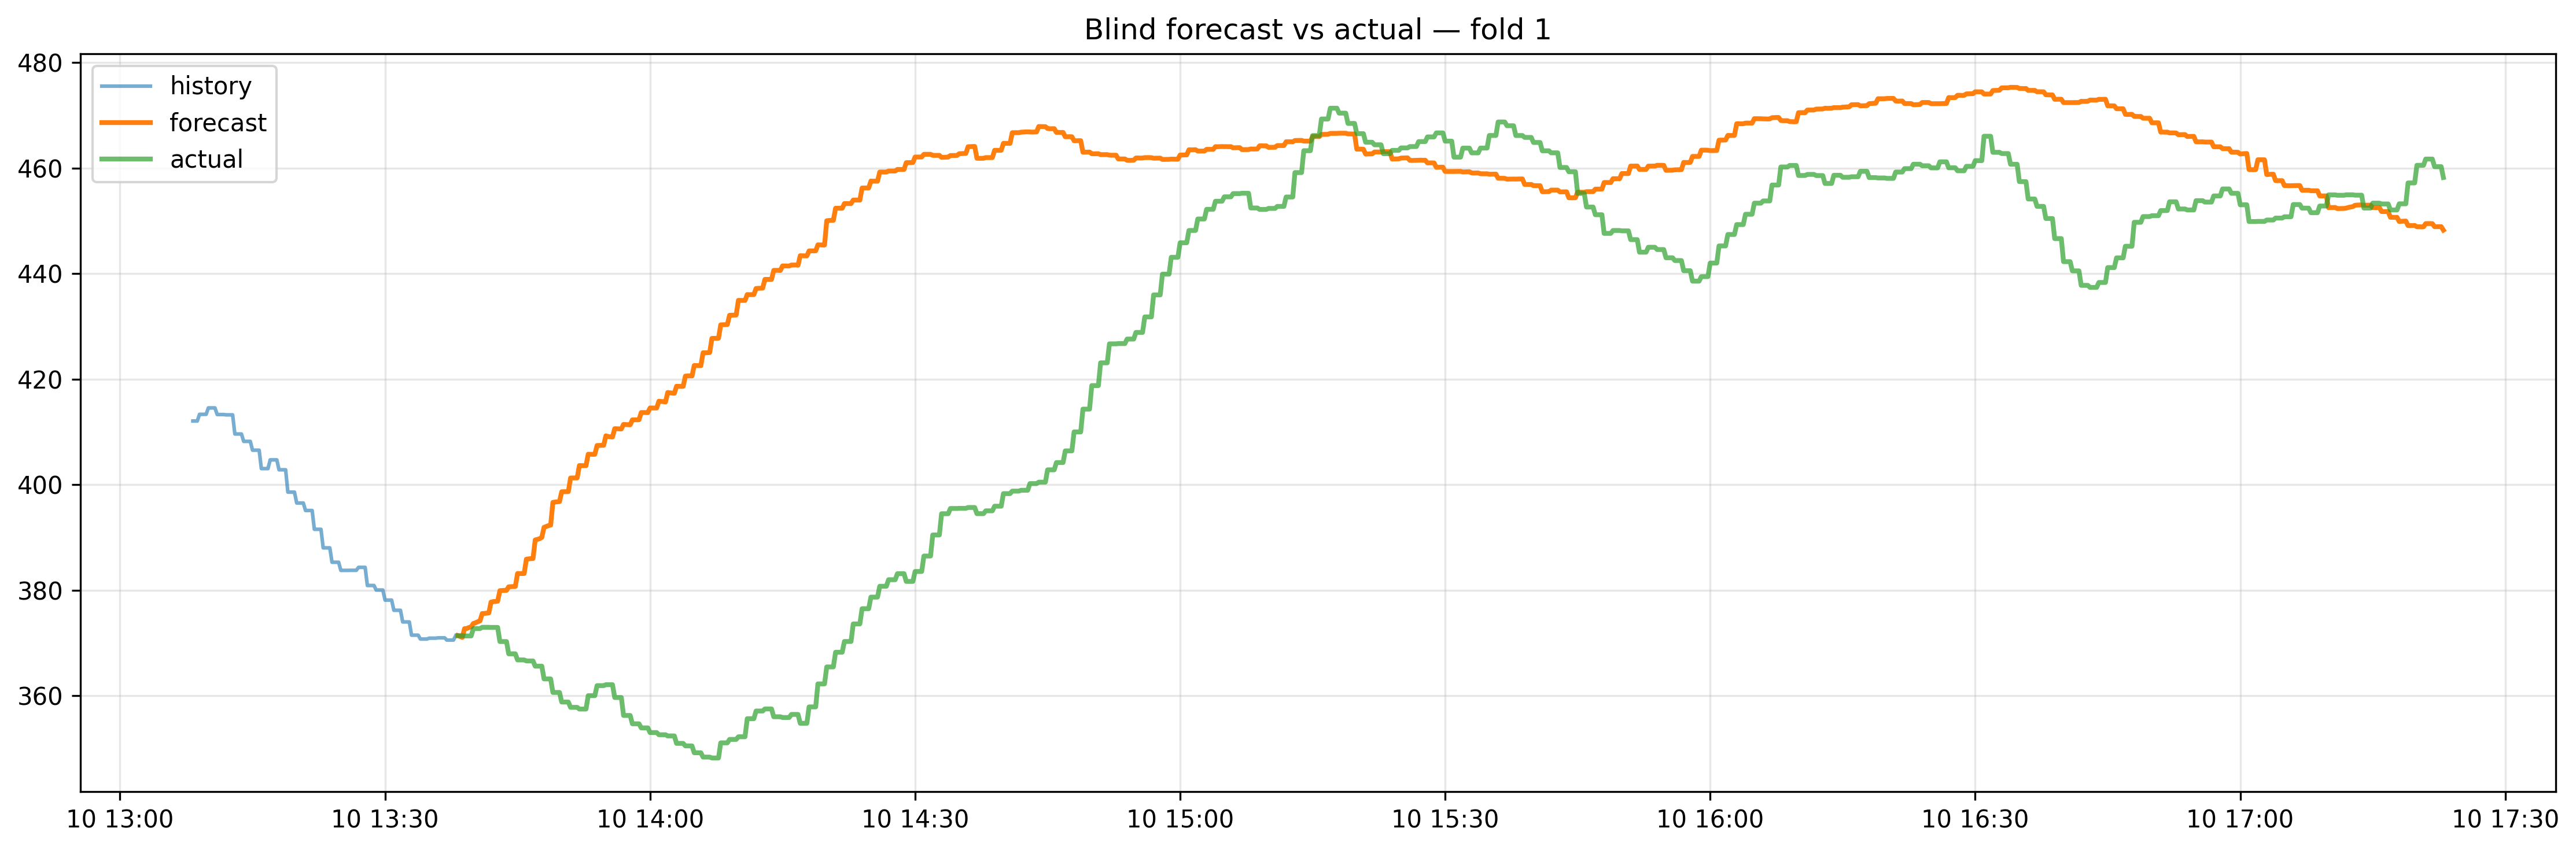

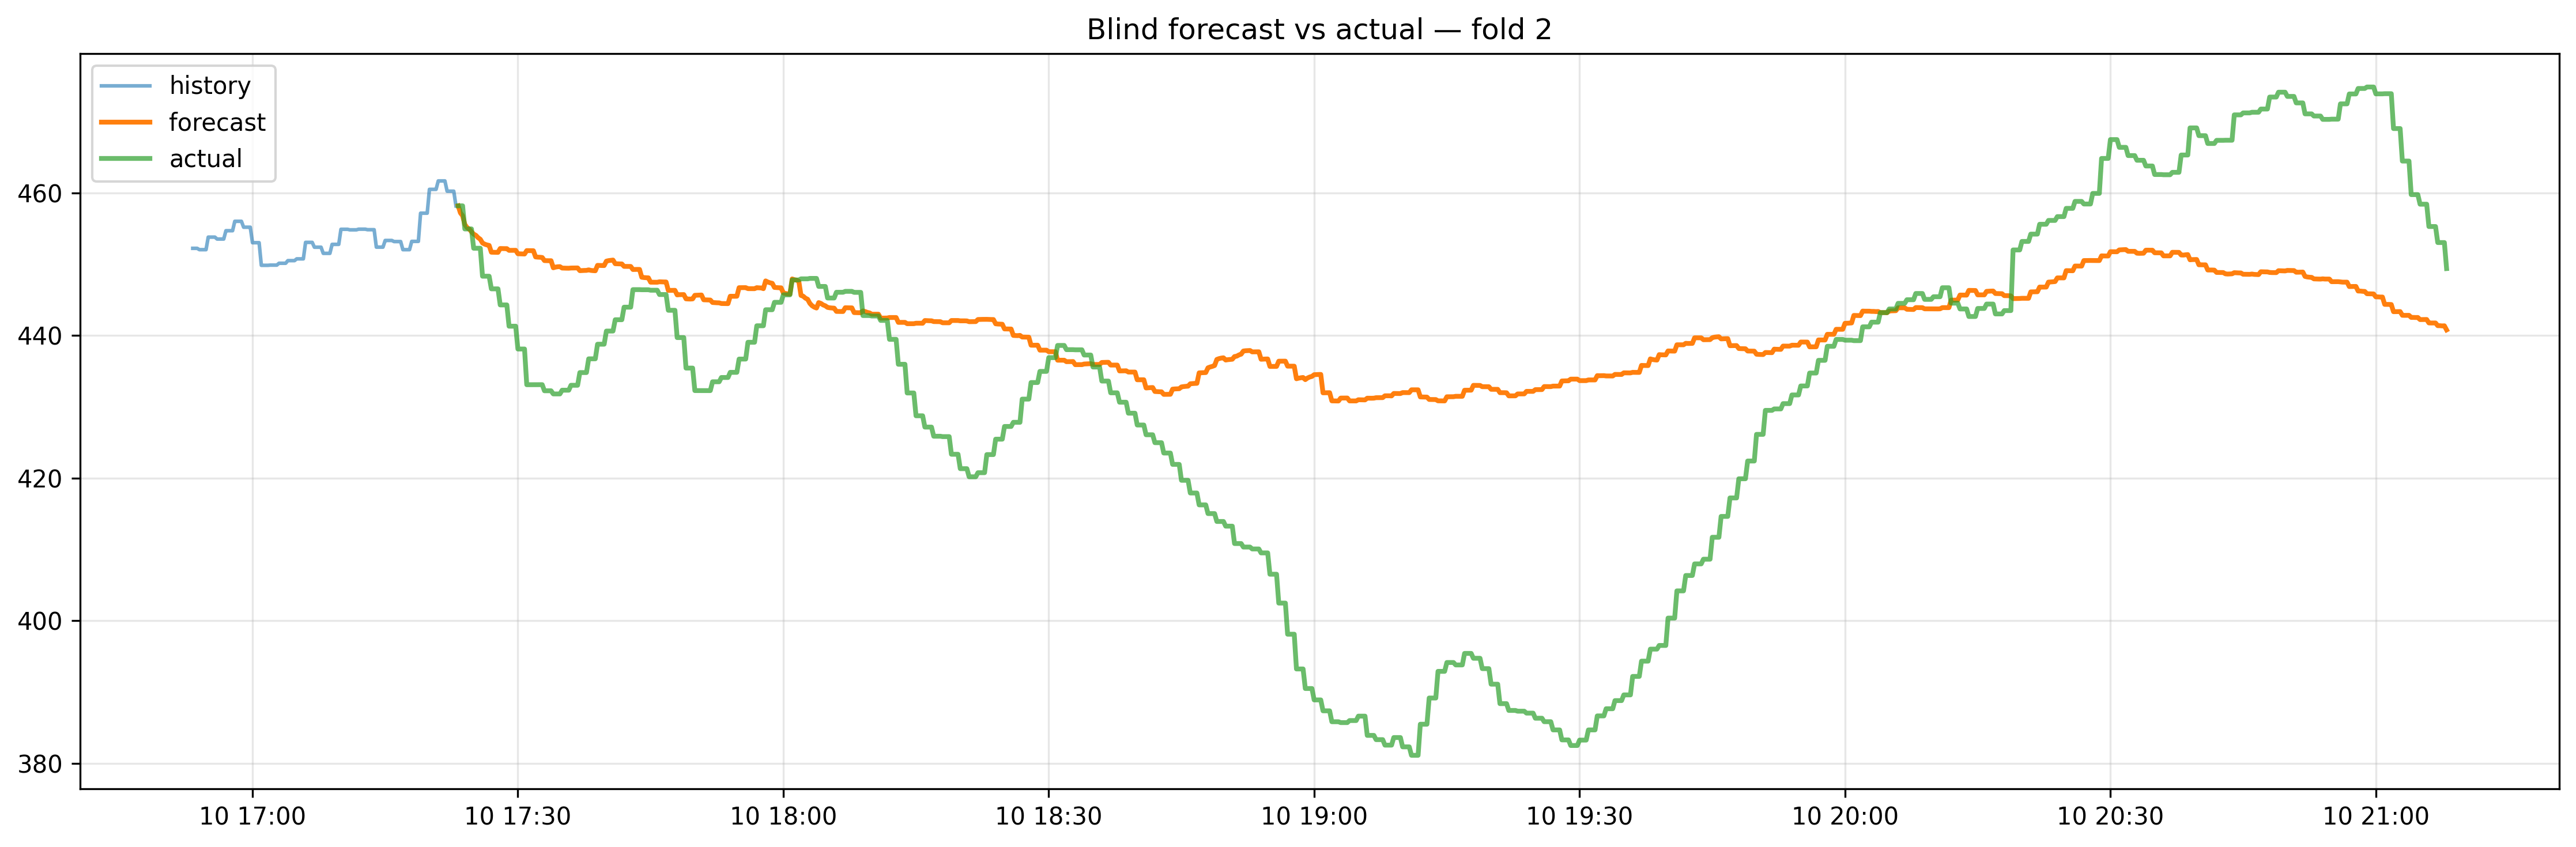

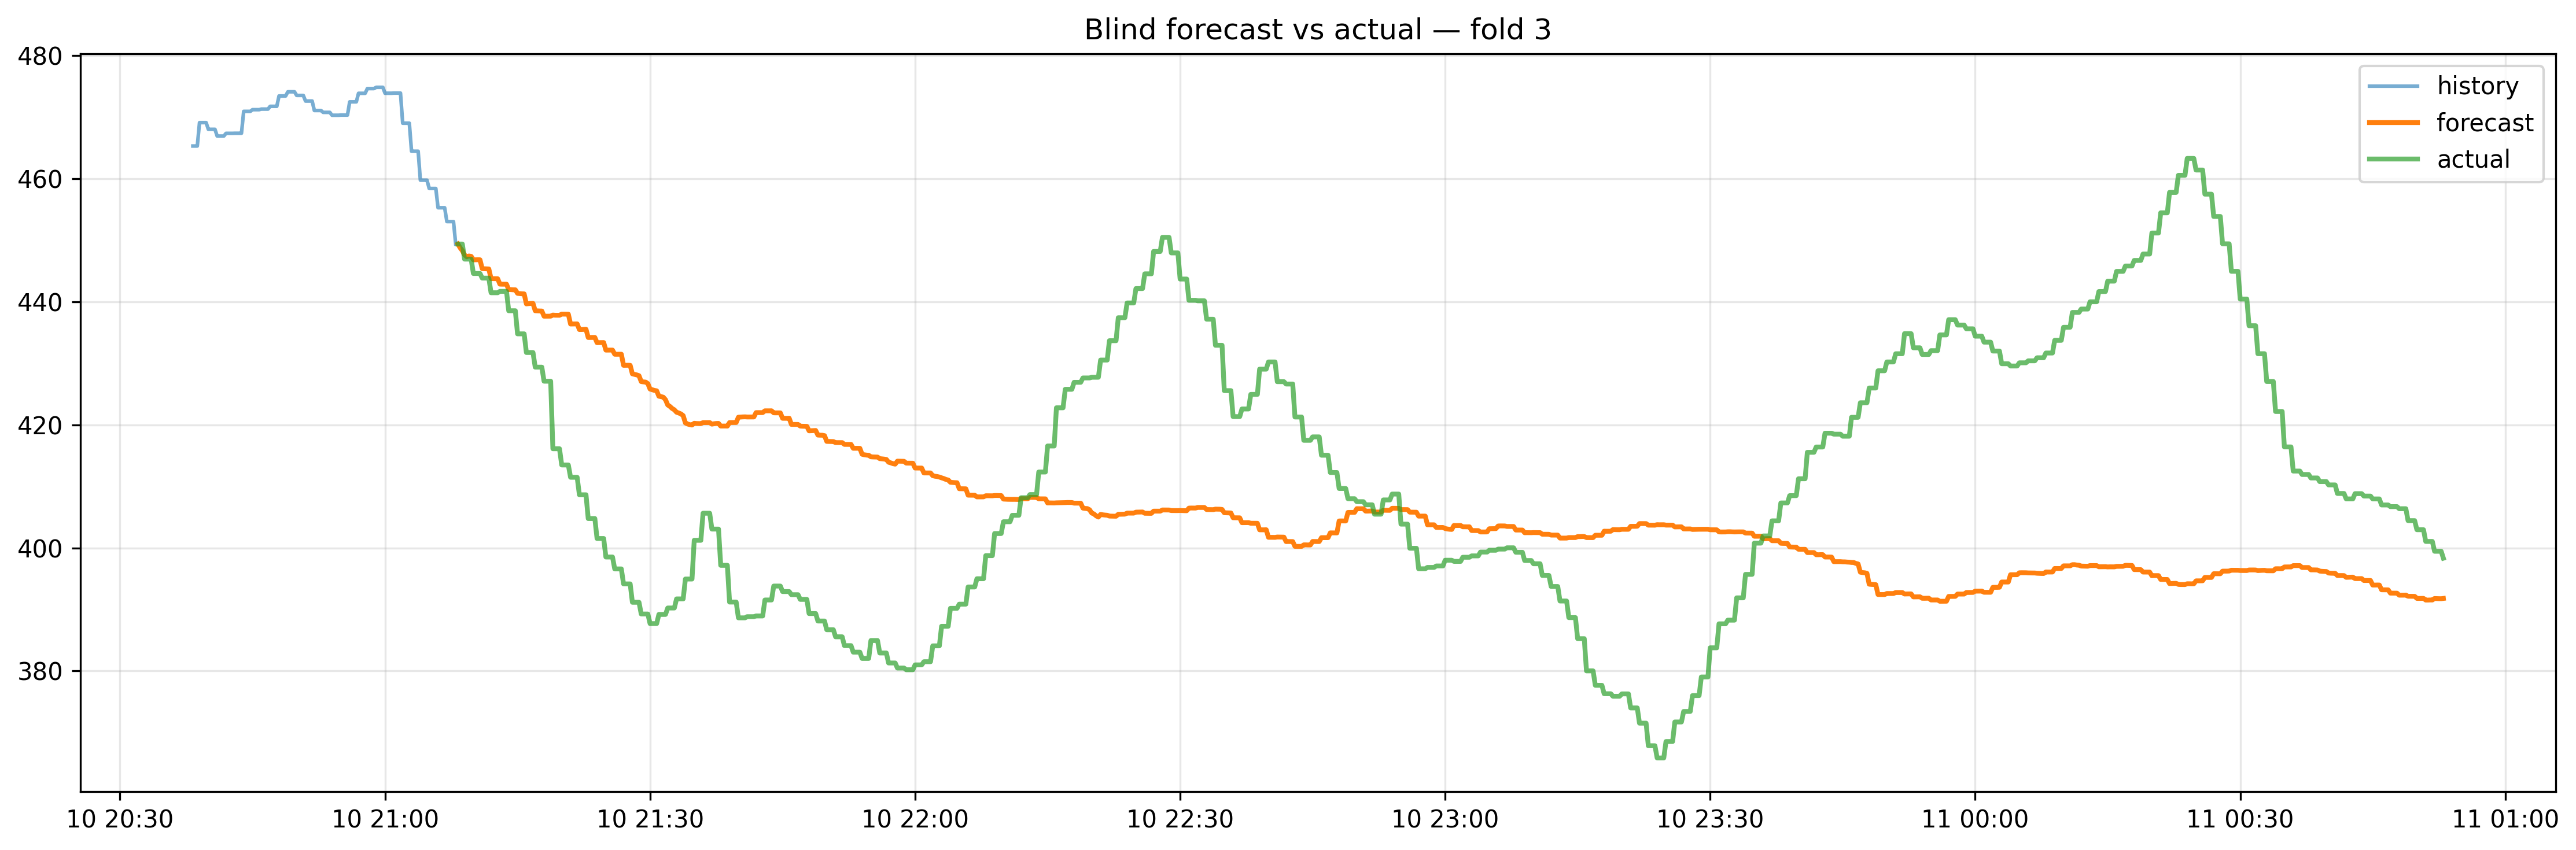

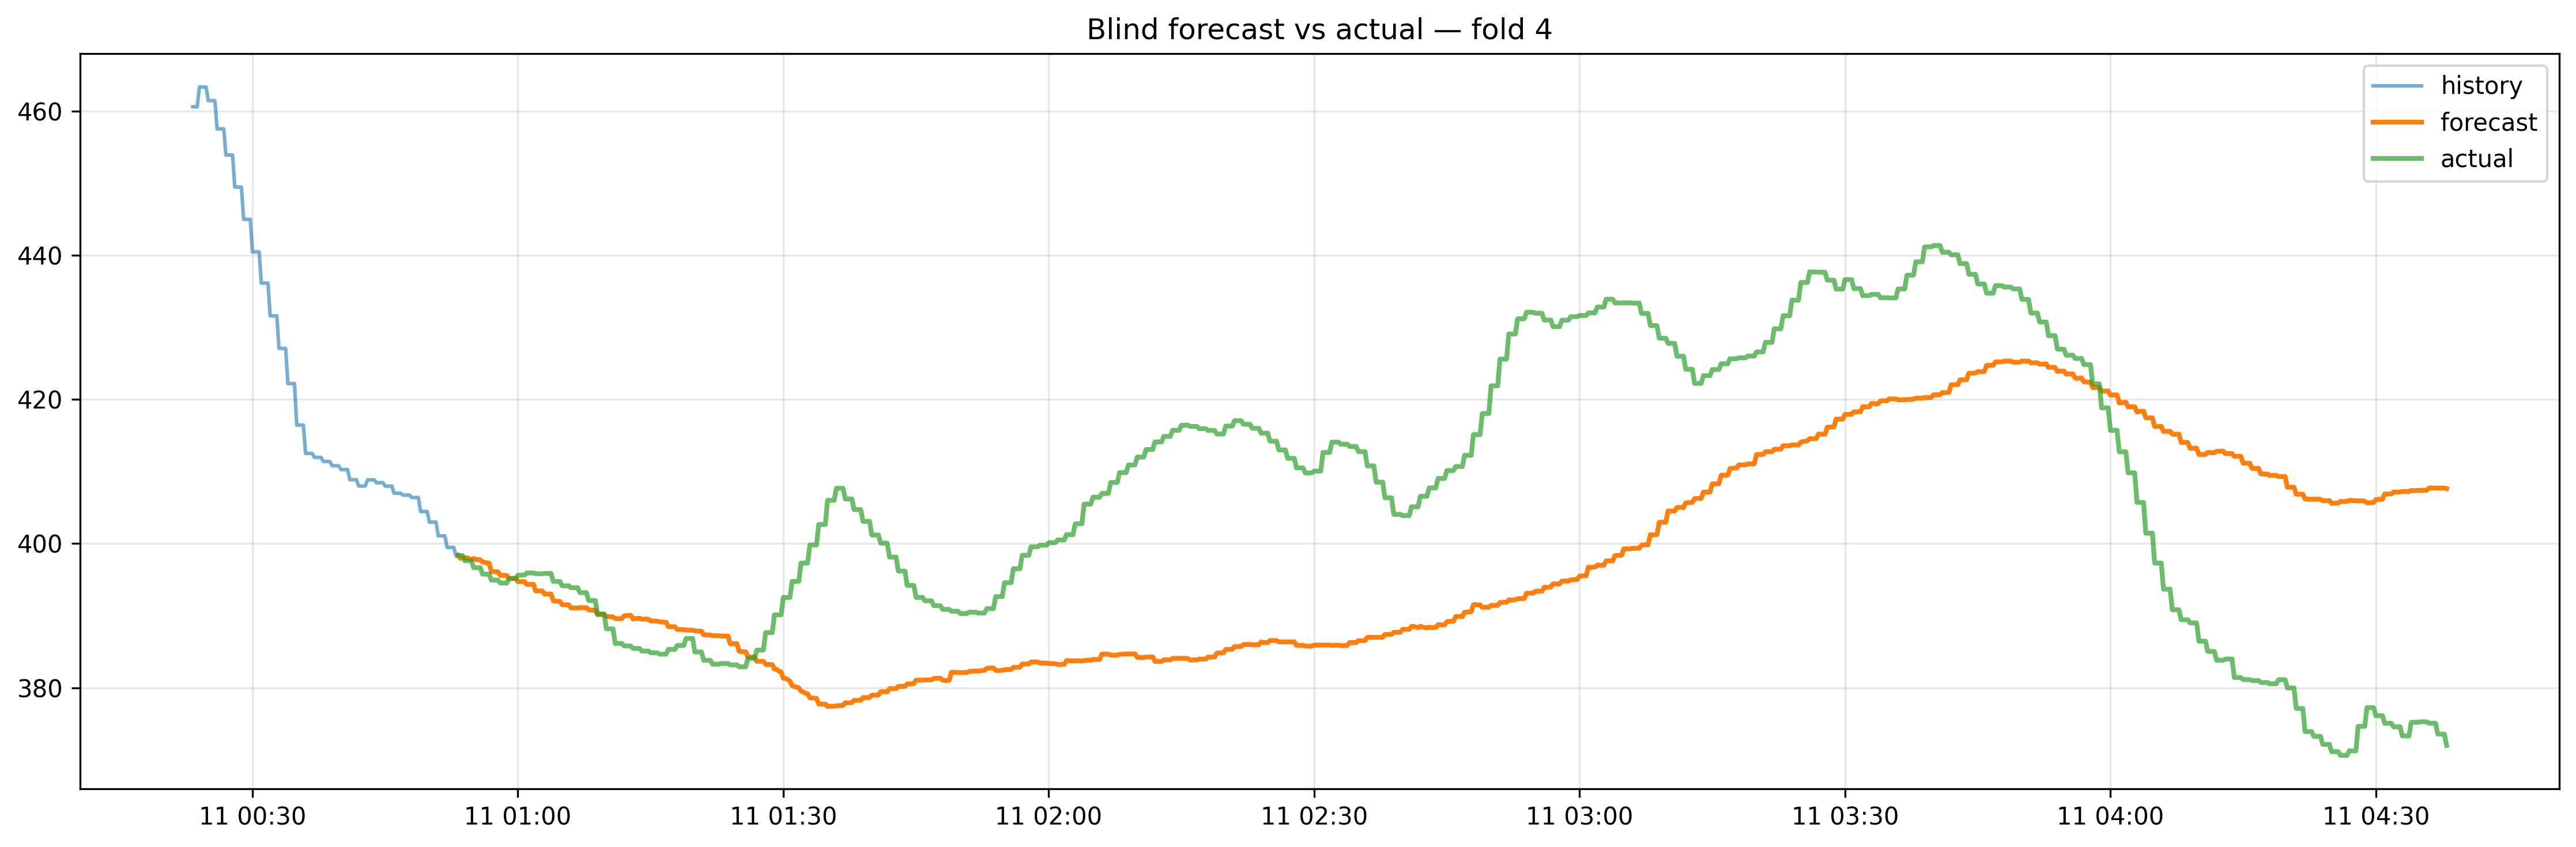

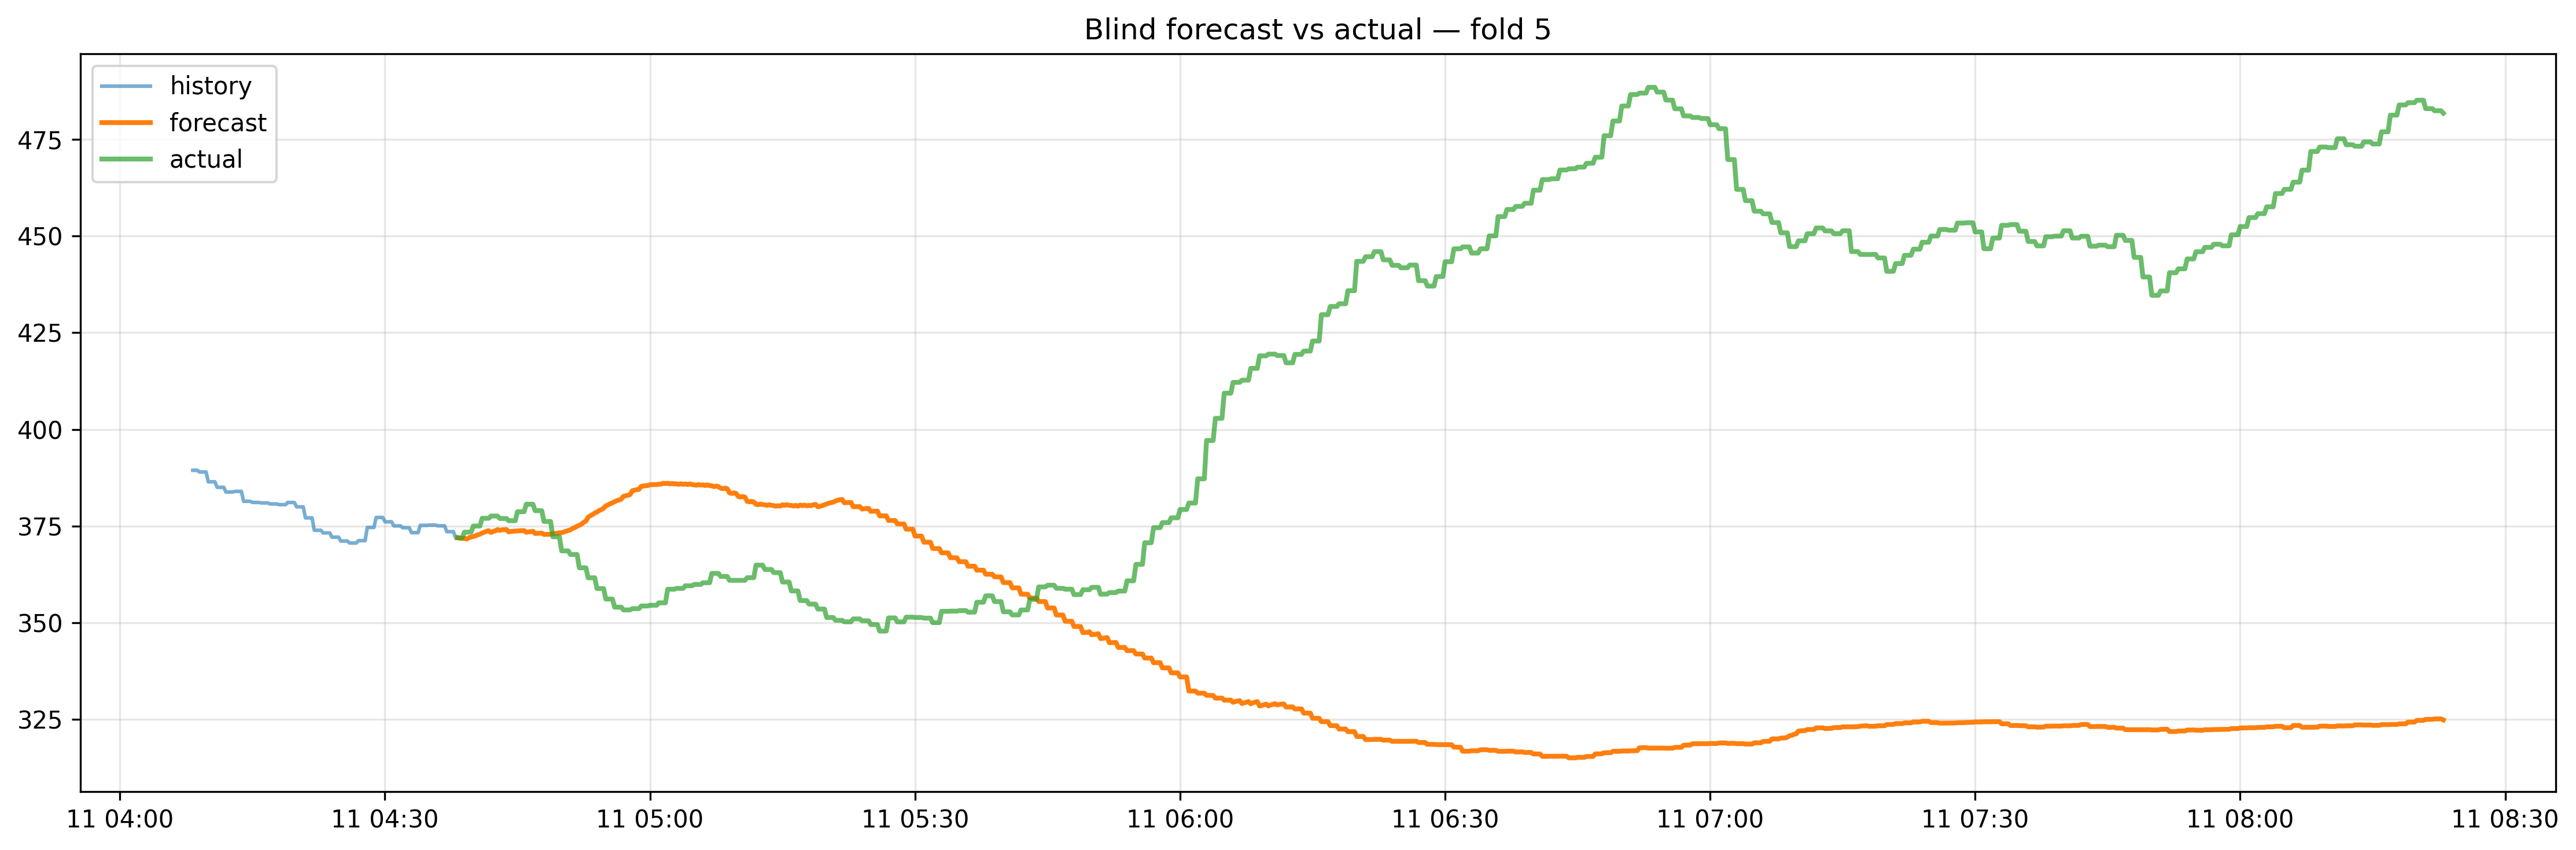

In [7]:
# ── Кросс-валидация с TimeSeriesSplit ─────────────────────────────────
n_splits = 5 # Количество фолдов для кросс-валидации
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=900)

metrics_list = []
logging.info(f"Запускаю кросс-валидацию на {n_splits} фолдах...")
df_for_cv = pd.concat([df_train_val, df_train_val_val])

for i, (train_index, val_index) in enumerate(tscv.split(df_for_cv)):
    logging.info(f"\n--- Фолд {i+1}/{n_splits} ---")
    df_train_fold = df_for_cv.iloc[train_index]
    df_val_fold = df_for_cv.iloc[val_index]
    logging.info(f"Размер train фолда {i+1}: {len(df_train_fold)}")
    logging.info(f"Размер val фолда {i+1}: {len(df_val_fold)}")
    logging.info(f"Период фолда {i+1}: {df_train_fold.index[0]} - {df_train_fold.index[-1]}")

    # Модель для фолда
    model_fold = DecompositionImprovedTrendModel(
        horizon=len(df_val_fold), # Горизонт равен размеру валидационного сета
        trend_model_type='global',
        trend_window_size=5760,
        depth=15,
        l2_leaf_reg=40,
        learning_rate=0.015,
        iterations=500,
        rsm=0.75,
        early_stopping_rounds=300,
        use_cyclic_features=False,
        ema_alpha=0.4,
    )
    
    logging.info("Начинаю обучение на фолде...")
    model_fold.fit(
        train_df=df_train_fold, 
        target_col='common_cad_avg1h',
        val_df=df_val_fold
    )
    logging.info("Обучение на фолде завершено.")

    # Прогноз на валидационной части фолда
    y_pred_fold = model_fold.predict(df_hist=df_train_fold)
    y_true_fold = df_val_fold['common_cad_avg1h'].reindex(y_pred_fold.index).dropna()
    
    # Выравниваем y_pred_fold по индексам y_true_fold, чтобы избежать ошибок в метриках
    y_pred_fold = y_pred_fold.reindex(y_true_fold.index).dropna()
    
    if len(y_true_fold) > 0 and len(y_pred_fold) > 0:
        fold_metrics = global_metrics(y_true_fold, y_pred_fold)
        metrics_list.append(fold_metrics)
        logging.info(f"Метрики на фолде {i+1}: MAE={fold_metrics['MAE']:.1f}, RMSE={fold_metrics['RMSE']:.1f}, MAPE={fold_metrics['MAPE']:.2f}%")
        # ── график: история 3 сут + прогноз vs факт ──
        # hist_start = pred_idx[0] - pd.Timedelta(hours=1)
        pred_idx = y_pred_fold.index
        hist_start = pred_idx[0] - pd.Timedelta(minutes=30)
        plot_history_forecast(
            history  = df_train_fold.loc[hist_start:pred_idx[0], 'common_cad_avg1h'],
            forecast = pd.Series(y_pred_fold, index=pred_idx),
            actual   = y_true_fold,
            title    = f'Blind forecast vs actual — fold {i+1}',
            filename = f'plots/{model_name}/cv_fold_{i+1}_forecast_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}.png'
        )
    else:
        logging.info(f"На фолде {i+1} не получилось посчитать метрики (нет пересечения данных).")


# Усредненные метрики по кросс-валидации
if metrics_list:
    avg_metrics = {key: np.mean([m[key] for m in metrics_list]) for key in metrics_list[0]}
    logging.info("\n--- Результаты кросс-валидации (средние) ---")
    logging.info(f"CV Avg • MAE={avg_metrics['MAE']:.1f}  RMSE={avg_metrics['RMSE']:.1f}  MAPE={avg_metrics['MAPE']:.2f}%")
else:
    logging.info("\nНе удалось собрать метрики ни на одном из фолдов.")


# ── Обучение финальной модели на всех данных (train+val) ───────────────
logging.info("\nНачинаю обучение финальной модели на всех данных train+val...")
final_model = DecompositionImprovedTrendModel(
    horizon=len(df_hold), # Горизонт прогноза равен размеру hold-out
    trend_model_type='global',
    trend_window_size=5760,
    depth=15,
    l2_leaf_reg=40,
    learning_rate=0.015,
    iterations=500,
    rsm=0.75,
    early_stopping_rounds=300,
    use_cyclic_features=False,
    ema_alpha=0.4,
    
)

final_model.fit(
    train_df=df_train_val, 
    target_col='common_cad_avg1h',
    val_df=df_train_val_val,
)
logging.info("Финальная модель успешно обучена!")
logging.info(f"Параметры модели: {final_model.cb_params}")
final_model.save(model_name)

In [8]:
# ── Прогноз на будущее (hold-out) ──────────────────────────
logging.info("\nДелаю прогноз на hold-out сете...")

y_pred_series = final_model.predict(df_hist=pd.concat([df_train_val, df_train_val_val]))

logging.info("Прогноз готов!")

2025-06-18 17:22:10,703 - INFO - 
Делаю прогноз на hold-out сете...
2025-06-18 17:23:17,243 - INFO - Прогноз готов!


In [9]:
# Подготавливаем данные для сравнения
pred_idx = y_pred_series.index
y_true = df_hold['common_cad_avg1h'].reindex(y_pred_series.index).dropna()
y_pred = y_pred_series.reindex(y_true.index).dropna() # Убедимся, что все выровнено

logging.info(f"Длина прогноза: {len(y_pred)}, Длина реальных данных: {len(y_true)}")

2025-06-18 17:23:17,275 - INFO - Длина прогноза: 908, Длина реальных данных: 908


2025-06-18 17:23:17,286 - INFO - Blind ~4h test • MAE=44.4  RMSE=52.0  MAPE=12.01%  on 908 valid points


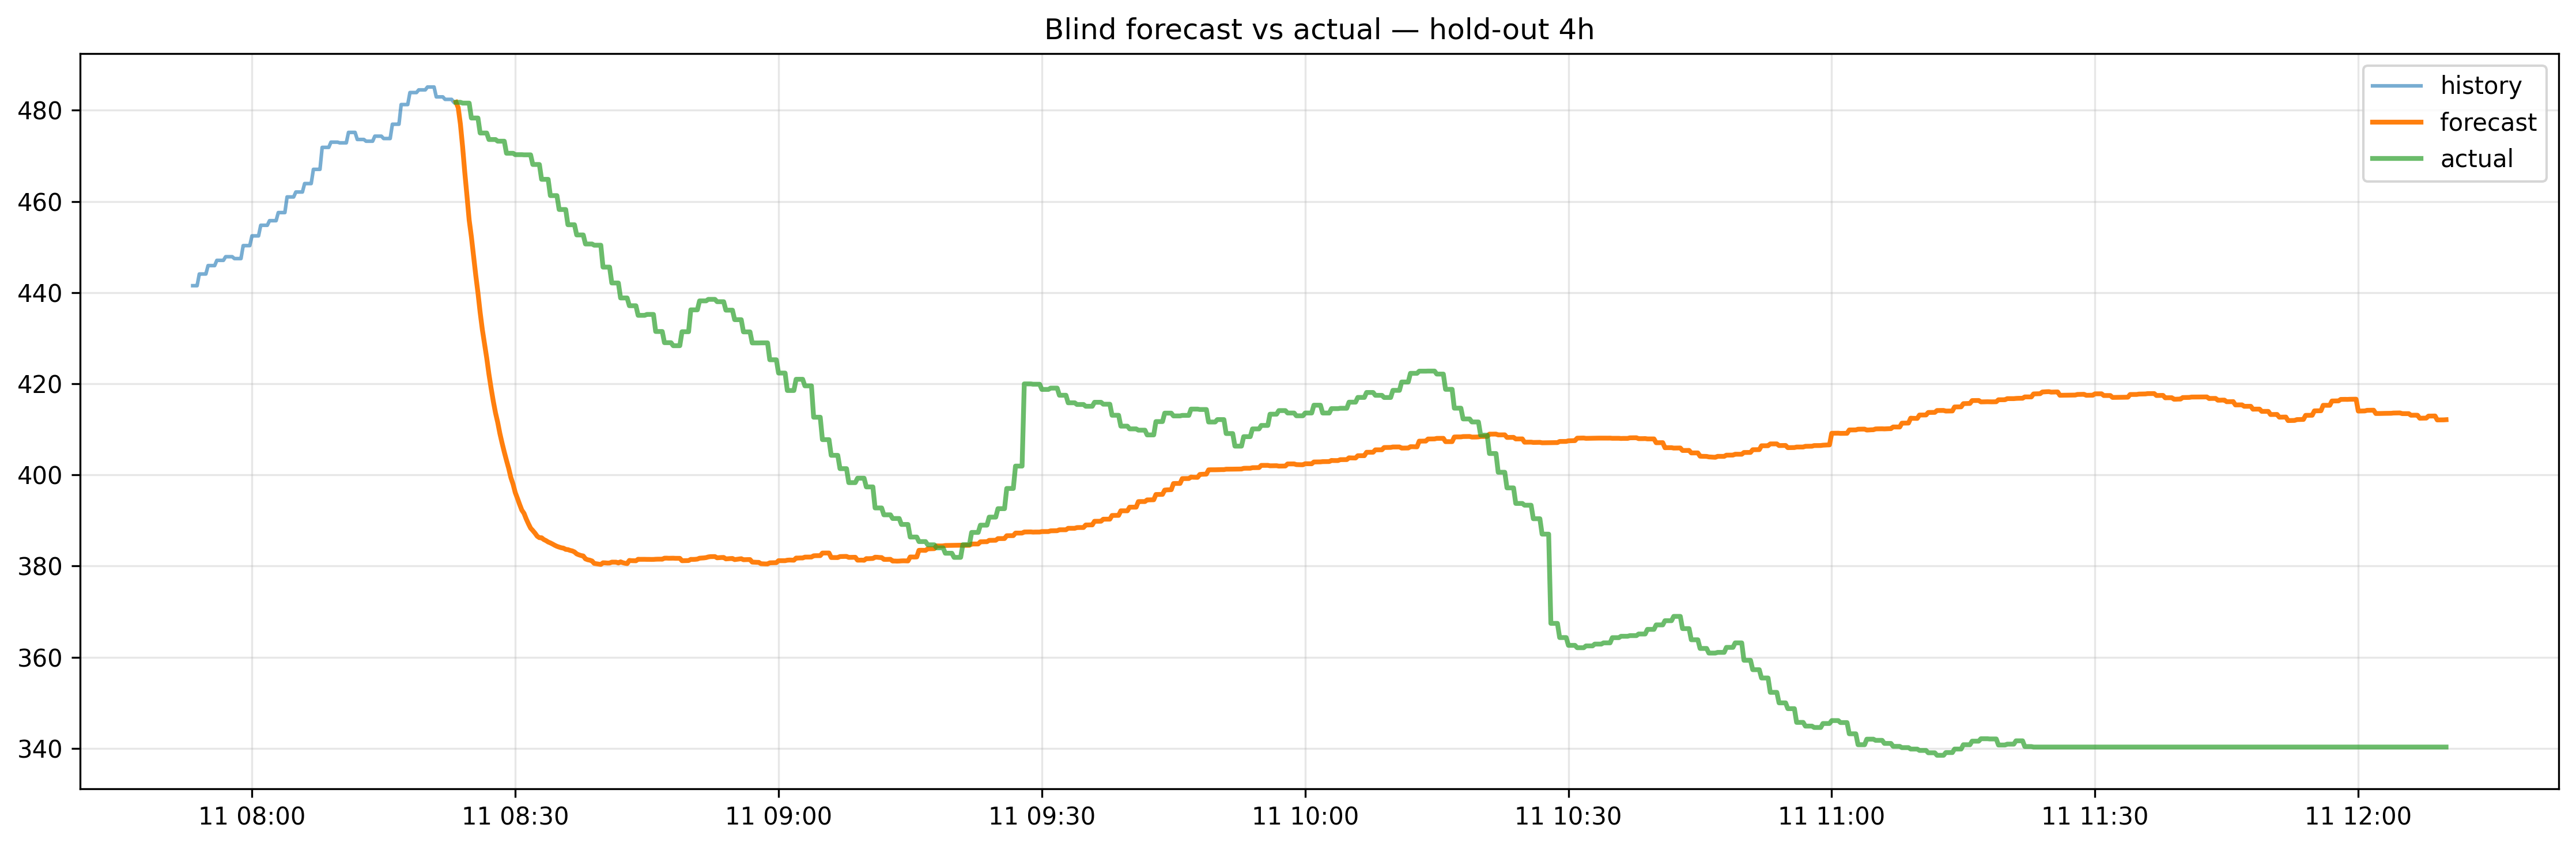

In [10]:
# y_true и y_pred уже созданы в предыдущей ячейке

metrics = global_metrics(y_true, y_pred)
logging.info(f"Blind ~4h test • MAE={metrics['MAE']:.1f}  RMSE={metrics['RMSE']:.1f}  MAPE={metrics['MAPE']:.2f}%  "
      f"on {len(y_true)} valid points")

# ── график: история 3 сут + прогноз vs факт ──
# hist_start = pred_idx[0] - pd.Timedelta(hours=1)
hist_start = pred_idx[0] - pd.Timedelta(minutes=30)
plot_history_forecast(
    history  = df.loc[hist_start:pred_idx[0], 'common_cad_avg1h'],
    forecast = pd.Series(y_pred, index=pred_idx),
    actual   = y_true,
    title    = 'Blind forecast vs actual — hold-out 4h',
    filename = f'plots/{model_name}/final_hold_out_forecast_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}.png'
)

<Axes: >

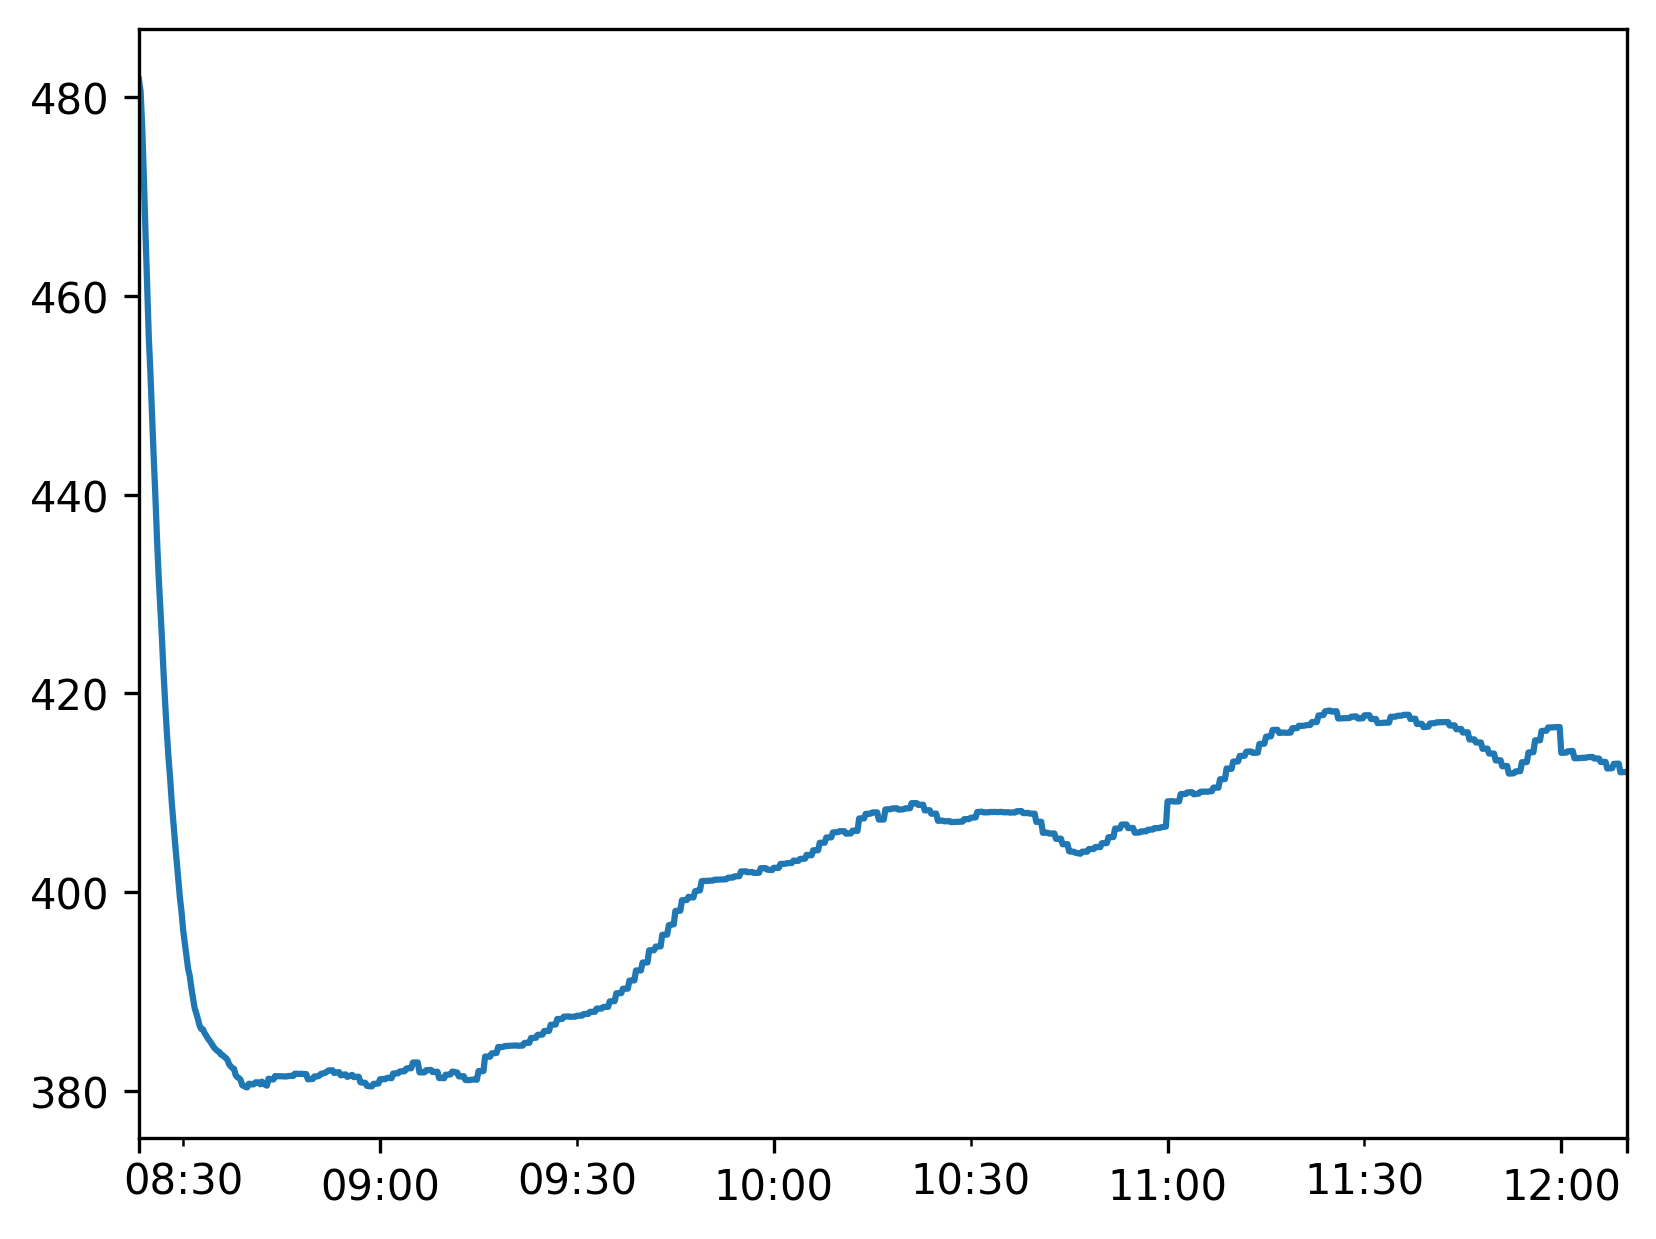

In [11]:
pd.Series(y_pred, index=pred_idx).plot()


2025-06-18 17:23:17,876 - INFO - 
*** Hold-out metrics ***
2025-06-18 17:23:17,877 - INFO -           value
MAE   44.427706
RMSE  52.006900
MAPE  12.006981
2025-06-18 17:23:17,884 - INFO - 
MAE by day:
2025-06-18 17:23:17,884 - INFO -         index        MAE
0  2024-12-11  44.427706


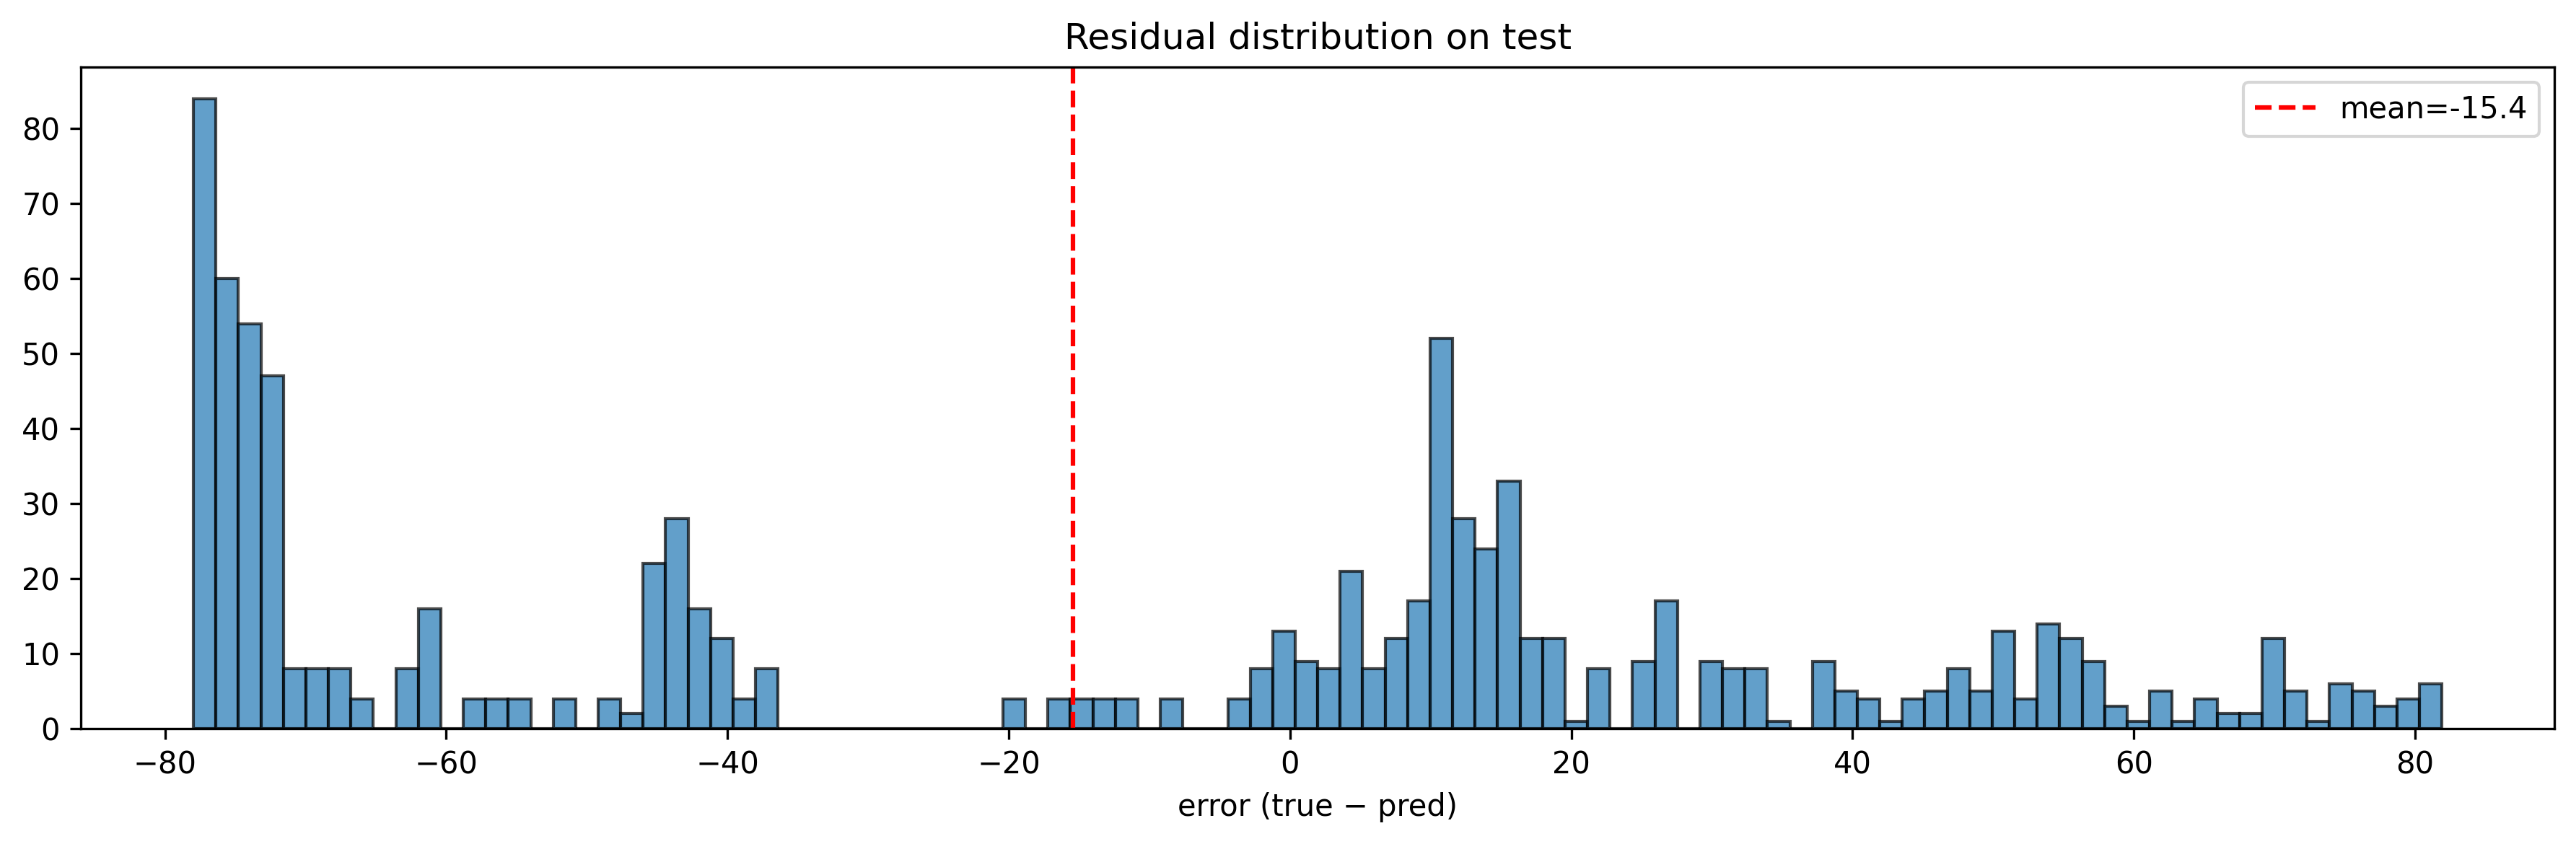

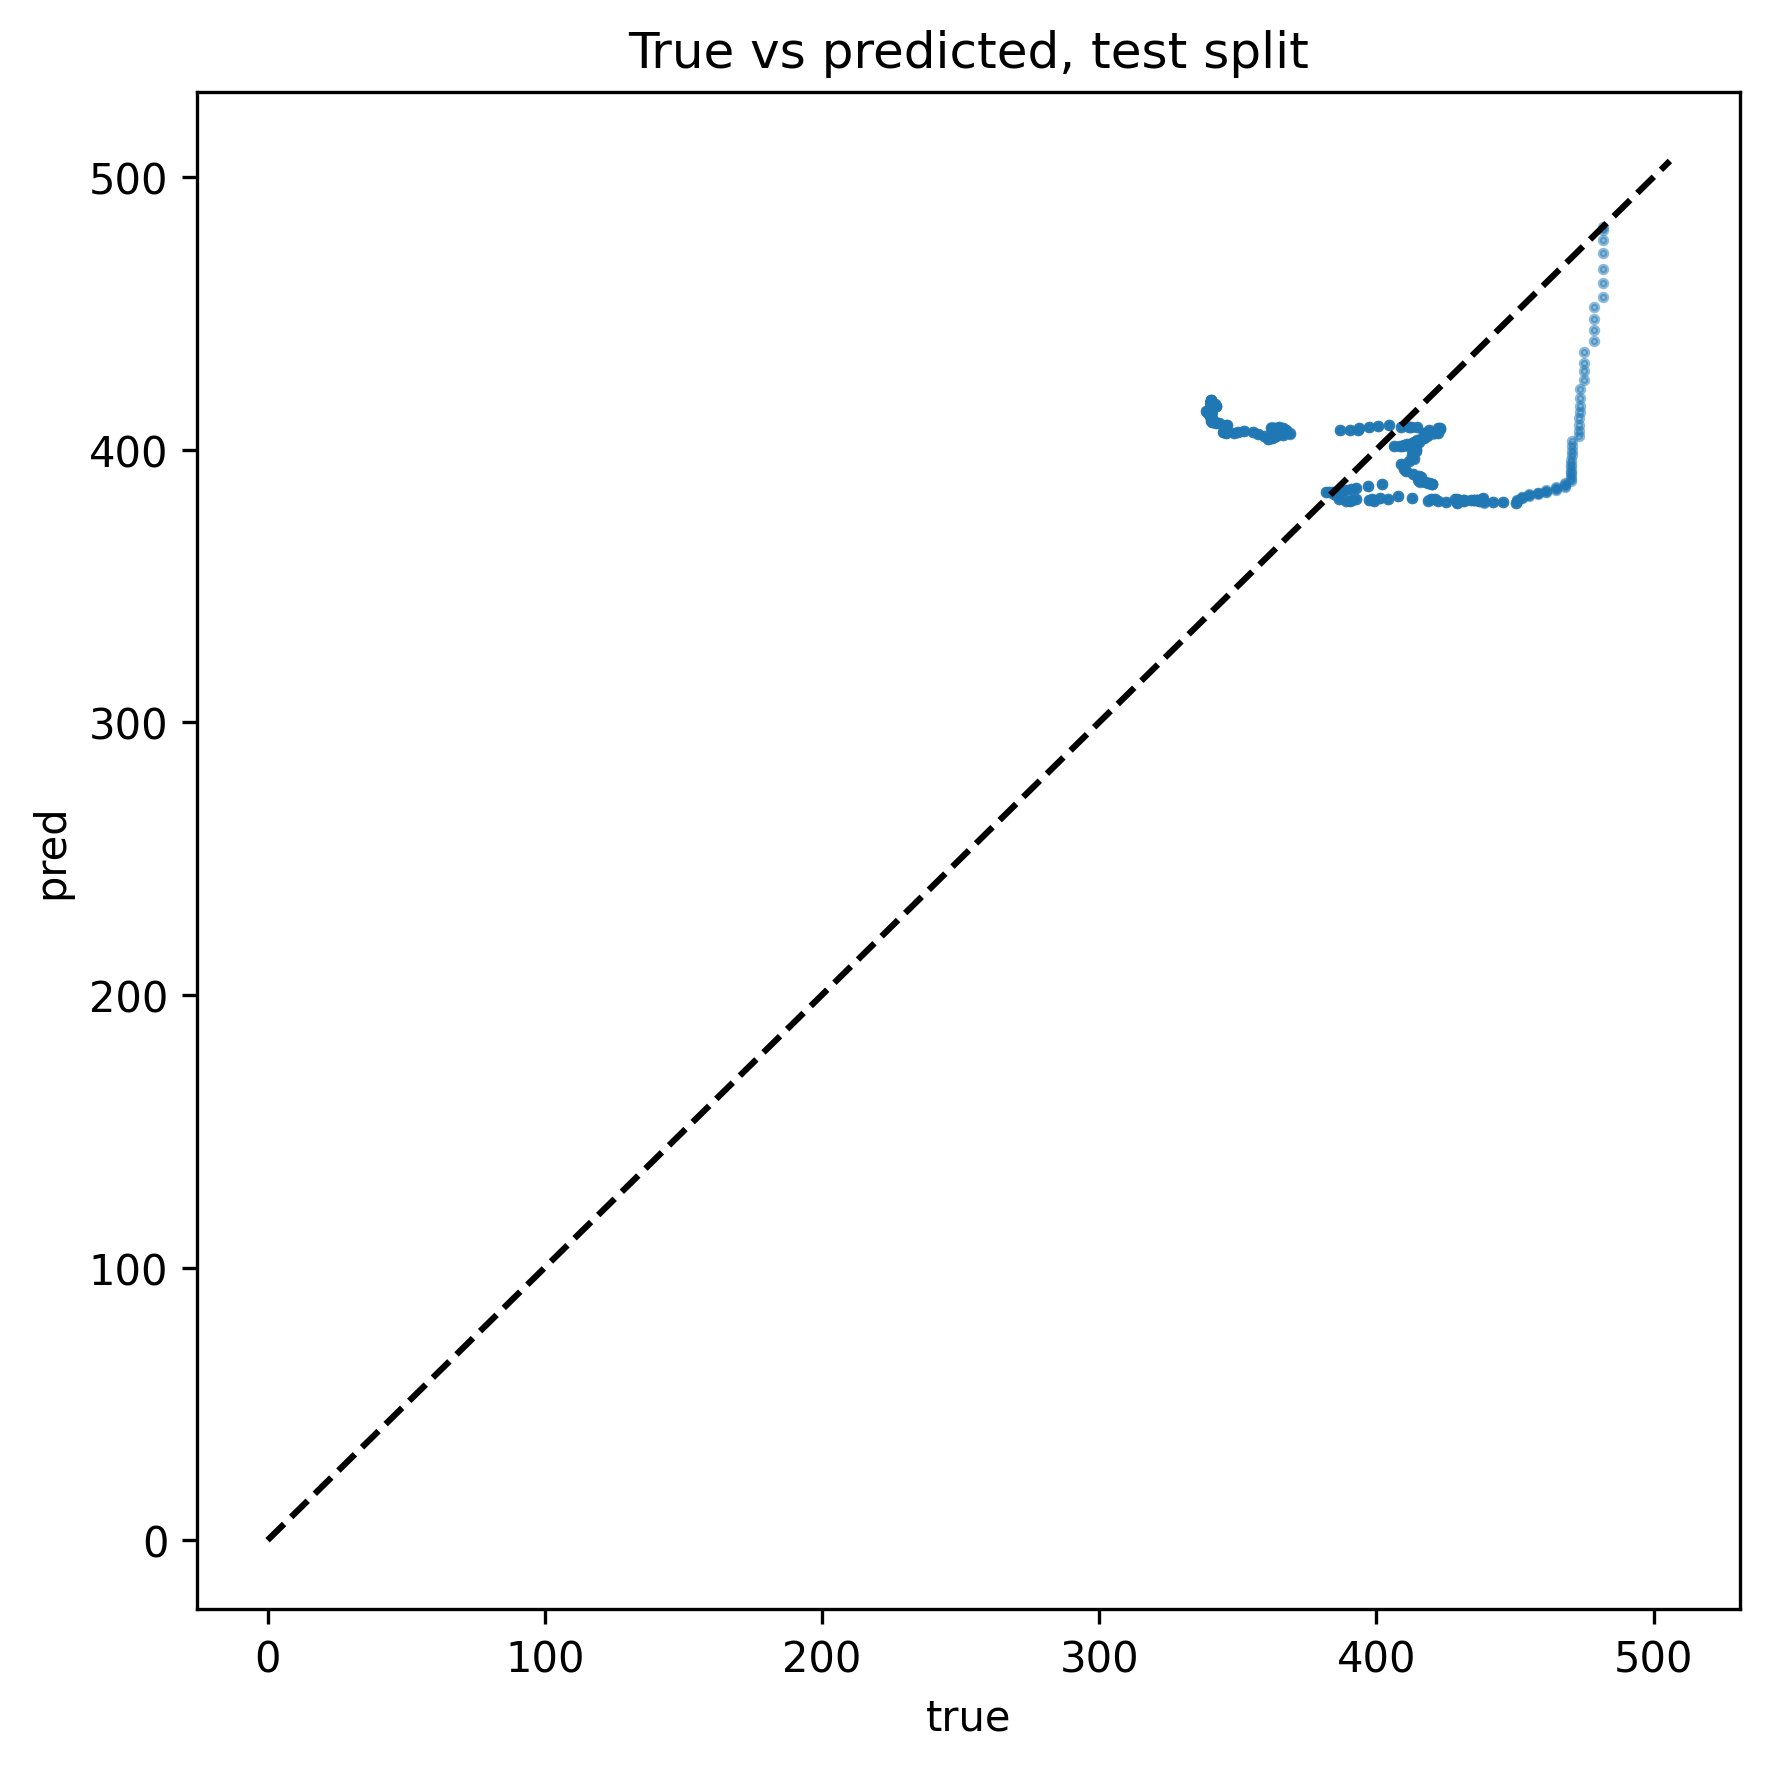

In [12]:
resid = y_true - y_pred


# ---------------------------------------------------
# 2.2  сводные метрики
# ---------------------------------------------------
metrics = global_metrics(y_true, y_pred)
metrics_df = pd.DataFrame([metrics]).T.rename(columns={0: "value"})
logging.info("\n*** Hold-out metrics ***")
logging.info(metrics_df)

# ---------------------------------------------------
# 2.3  метрики по суткам
# ---------------------------------------------------
daily_mae_result = daily_mae(y_true, y_pred)
logging.info("\nMAE by day:")
logging.info(daily_mae_result.tail())

# ---------------------------------------------------
# 2.4  распределение ошибок
# ---------------------------------------------------
plt.figure(figsize=(12,4))
plt.hist(resid, bins=100, alpha=.7, edgecolor='black')
plt.axvline(resid.mean(), color='r', linestyle='--', label=f"mean={resid.mean():.1f}")
plt.title("Residual distribution on test")
plt.xlabel("error (true − pred)")
plt.legend(); plt.tight_layout(); 
plt.savefig(f'plots/{model_name}/residual_distribution_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}.png')
plt.show()
# ---------------------------------------------------
# 2.5  true vs pred scatter
# ---------------------------------------------------
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, s=3, alpha=0.5)
lim = [0, max(y_true.max(), y_pred.max())*1.05]
plt.plot(lim, lim, 'k--')
plt.xlabel("true"); plt.ylabel("pred")
plt.title("True vs predicted, test split")
plt.tight_layout(); 
plt.savefig(f'plots/{model_name}/true_vs_pred_scatter_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}.png')
plt.show()



2025-06-18 17:23:19,254 - INFO -                    feature  importance
0            f_resid_lag_2   23.790246
1      f_resid_roll_mean_4   20.448849
2            f_resid_lag_1   19.186225
3            f_resid_lag_4   17.855664
4     f_resid_roll_mean_96    6.555076
5    f_resid_roll_mean_192    1.036668
6   f_resid_roll_mean_4320    1.035880
7   f_resid_roll_mean_8640    0.999176
8   f_resid_roll_mean_5760    0.917445
9    f_resid_roll_std_8640    0.848165
10    f_resid_roll_std_192    0.780566
11   f_resid_roll_std_4320    0.776949
12   f_resid_roll_std_5760    0.699350
13          f_resid_lag_96    0.659896
14        f_resid_lag_5760    0.653861
15   f_resid_roll_std_2880    0.633361
16     f_resid_roll_std_96    0.514223
17                time_idx    0.492063
18  f_resid_roll_mean_2880    0.484368
19   f_resid_roll_std_1920    0.419885


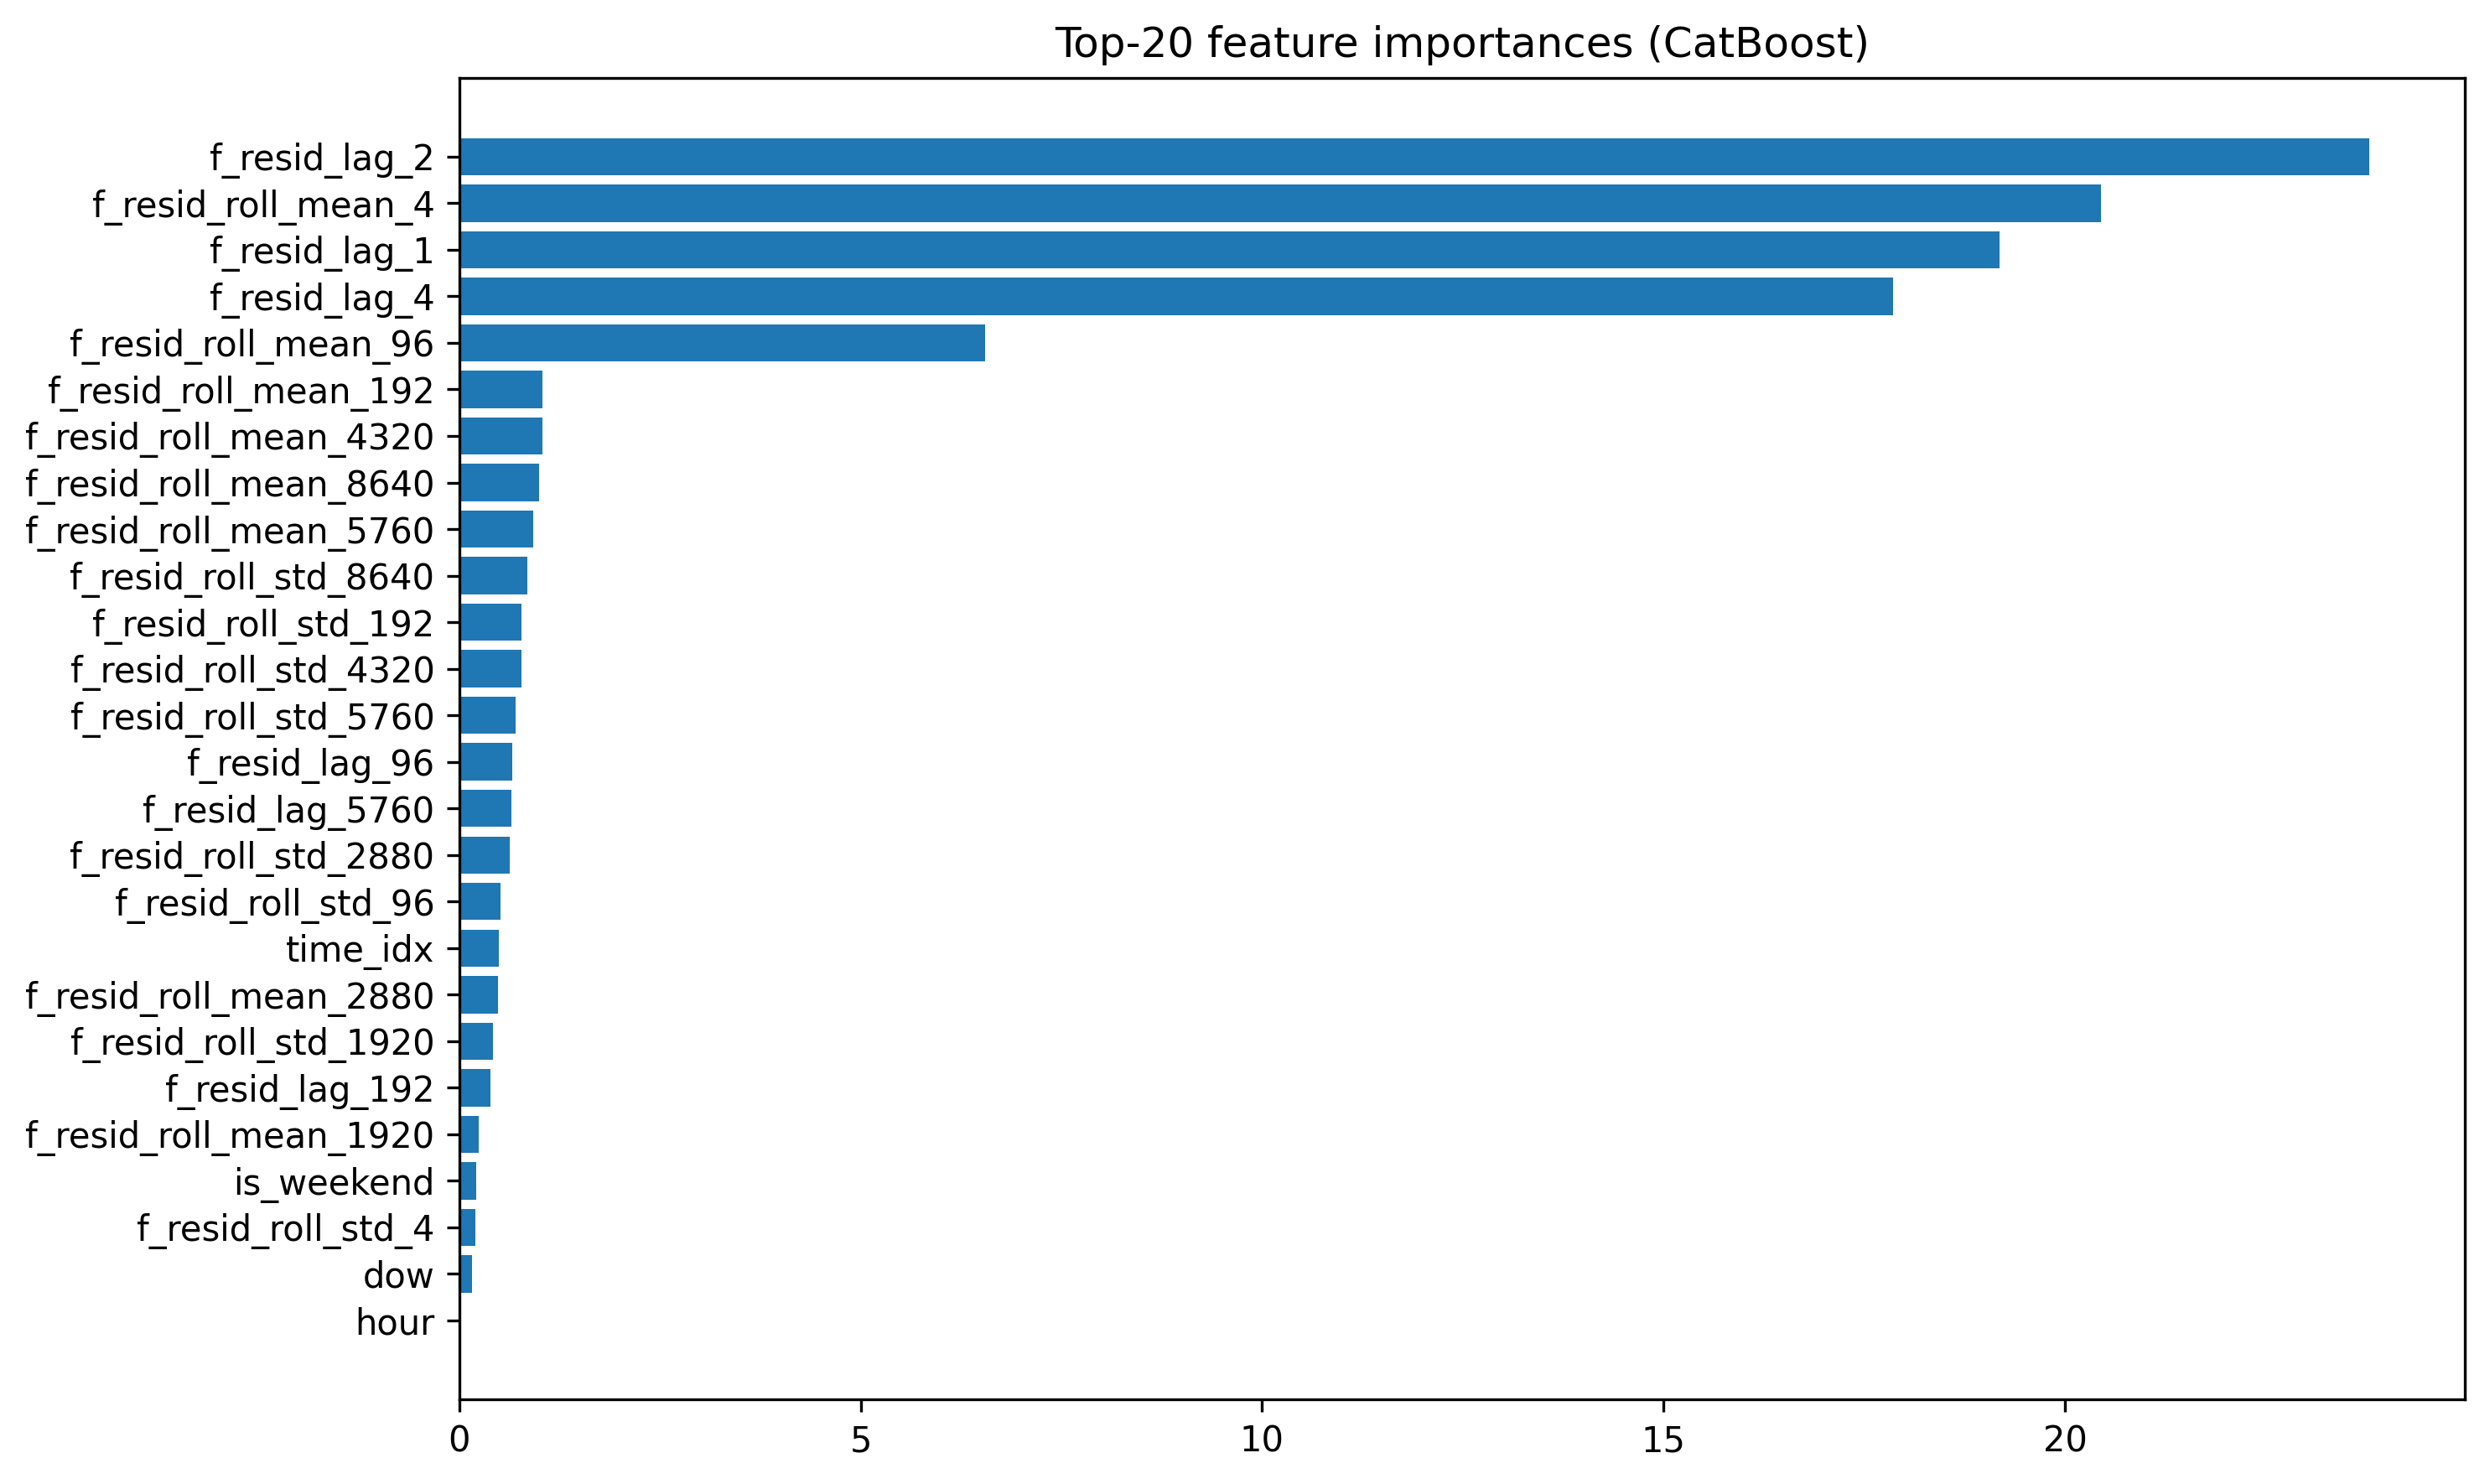

In [13]:
model = final_model
feat_names = model.model.feature_names_        # ← то, что CatBoost запомнил
importances = model.model.get_feature_importance(type='FeatureImportance')

# в один датафрейм
imp_df = (pd.DataFrame({"feature": feat_names,
                        "importance": importances})
            .sort_values(by="importance", ascending=False)
            .reset_index(drop=True))

logging.info(imp_df.head(20))
# ---------------------------------------------------
#  топ-20 на графике
# ---------------------------------------------------
plt.figure(figsize=(10,6))
plt.barh(imp_df.feature[::-1],
         imp_df.importance[::-1])
# plt.barh(imp_df.feature.head(20)[::-1],
#          imp_df.importance.head(20)[::-1])
plt.title("Top-20 feature importances (CatBoost)")
plt.tight_layout();
plt.savefig(f'plots/{model_name}/top_20_feature_importances_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}.png')
plt.show()
